# First experiment with imposed Q 

Here we infer the relaxation Qrad(lat,p) from T for the control and Qimp = 1K/d run. 

In equilibrium, that is equal to minus Qeddy. 

In [13]:
import xarray as xr

In [96]:
ctlv = xr.open_dataset('/Users/bmapes/Box/Mapes-Kirtman_AGCMdata/ControlNoMountain/vvel_Pressure_days_1-2400.nc')
ctlT = xr.open_dataset('/Users/bmapes/Box/Mapes-Kirtman_AGCMdata/ControlNoMountain/temp_Pressure_days_1-2400.nc')
expT = xr.open_dataset('/Users/bmapes/Box/Mapes-Kirtman_AGCMdata/Experiment1NoMountain/temp_Pressure_days_1-2400.nc')

In [99]:
ctlT

<xarray.Dataset> Size: 4GB
Dimensions:  (time: 2400, lev: 12, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 19kB 1950-01-01 1950-01-02 ... 1956-07-27
  * lev      (lev) float64 96B 1e+03 900.0 850.0 800.0 ... 200.0 100.0 20.0
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Data variables:
    t        (time, lev, lat, lon) float64 4GB ...

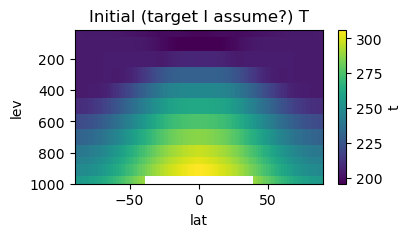

In [139]:
# Time zero is the target temperature I suppose? 
Tinit = ctlT.t[0].mean(dim='lon')

Tinit.plot(size=2, aspect=2);
plt.ylim([1000,10]); plt.title('Initial (target I assume?) T');

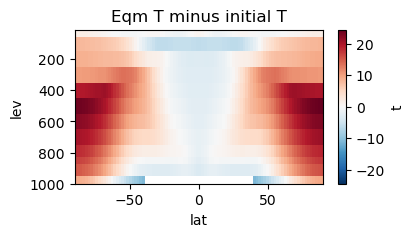

In [101]:
# eqT = Mean of later years, plot it minus initial T 

eqmT = ctlT.t[1000:].mean(dim=['time','lon'])
(eqmT - Tinit).plot(size=2, aspect=2)
plt.ylim([1000,10]); plt.title('Eqm T minus initial T');

# Need relaxation tau to infer Q 

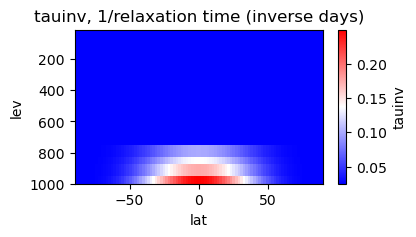

In [102]:
# Following Held & Suarez the Newtonian Damping Coefficients are
# lat and p Dependent. Here we produce those coeffiencients

jmax = ctlT.lat.size   # 96
imax = ctlT.lon.size   # 192
kmax = ctlT.lev.size   # 12
coslat = np.cos(ctlT.lat * np.pi / 180.0)
plevs = ctlT.lev

ka = 1.0 / (40.0*86400.0)
ks = 1 / (4.0*86400.0)
slb = 700  # 0.7 sigma level in Held-Suarez spec

vert = (plevs-slb) / (1000-slb)
vert = np.where(vert < 0.0, 0.0, vert)
kt = np.zeros((kmax, jmax, imax))
for j in range(jmax):
    for k in range(kmax):
        kt[k, j, :] = ka + (ks - ka)*vert[k]*(coslat[j]**4.0)

tauinv = kt[:, :, 0]*86400.
ctlT = ctlT.assign(tauinv=(['lev', 'lat'], tauinv))   

# Relaxation time tau
ctlT.tauinv.plot(size=2, aspect=2, cmap='bwr')
plt.ylim([1000,10]);
plt.title('tauinv, 1/relaxation time (inverse days)');

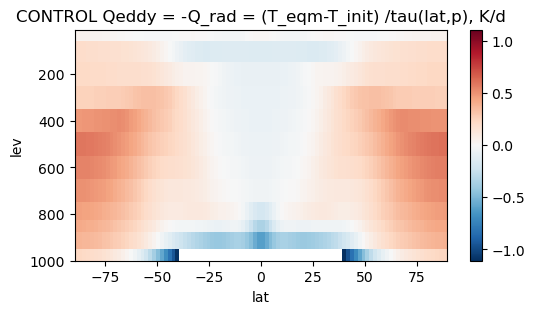

In [140]:
# Eddy heating rate Q in K/d inferred as -Qr 
Q = ((eqmT - Tinit)* ctlT.tauinv)   # K/d 
Q.plot(size=3,aspect=2)
plt.ylim([1000,10]);
plt.title('CONTROL Qeddy = -Q_rad = (T_eqm-T_init) /tau(lat,p), K/d');

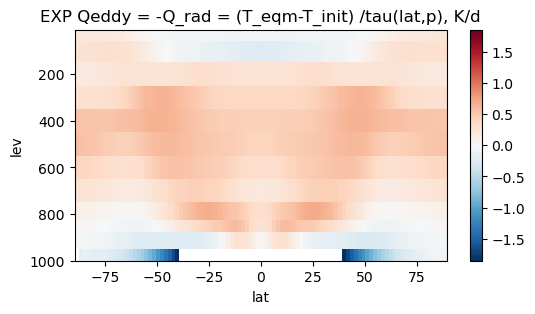

In [141]:
# EXPERIMENT inferred eddy Heating rate in K/d 

eqmT2 = expT.t[1000:].mean(dim=['time','lon'])
Tinit2 = expT.t[0].mean(dim='lon')

Q2 = ((eqmT2 - Tinit2)* ctlT.tauinv)   # K/d 

Q2.plot(size=3,aspect=2)
plt.ylim([1000,10]);
plt.title('EXP Qeddy = -Q_rad = (T_eqm-T_init) /tau(lat,p), K/d');

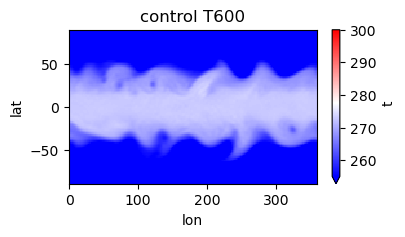

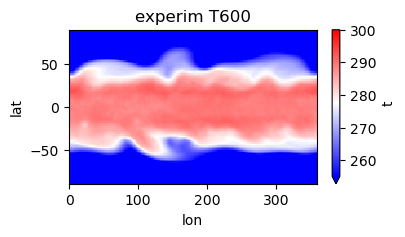

In [133]:
ctlT.t[2000].sel(lev=600).plot(size=2,aspect=2,vmin=255,vmax=300,cmap='bwr');plt.title('control T600');
expT.t[2000].sel(lev=600).plot(size=2,aspect=2,vmin=255,vmax=300,cmap='bwr');plt.title('experim T600');